# Agentic Research Copilot: Multi-Agent RAG System

This notebook implements a basic end-to-end multi-agent RAG system for scholarly
question answering over a curated PDF corpus. The workflow consists of:

- Planner agent
- Retriever agent
- Writer agent
- Reflector agent

The system uses a FAISS vector store over PDF chunks and a LangGraph workflow
to coordinate the agents.

In [ ]:
# If needed, uncomment and run once
#%pip install langchain langchain-community langchain-text-splitters langchain-huggingface faiss-cpu pypdf openai langgraph python-dotenv pandas matplotlib

  Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 24.3 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import json
import operator
from typing import TypedDict, List, Annotated, Dict, Any

import pandas as pd
import matplotlib.pyplot as plt

from openai import OpenAI

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

from langgraph.graph import StateGraph, END

/Users/shreyaskullarni/Documents/Agentic_reasearch/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Local model / OpenAI-compatible endpoint config
BASE_URL = os.getenv("LOCAL_OPENAI_BASE_URL", "http://localhost:11434/v1")
API_KEY = os.getenv("LOCAL_OPENAI_API_KEY", "ollama")
MODEL_NAME = os.getenv("LOCAL_MODEL_NAME", "llama3.1")

client = OpenAI(base_url=BASE_URL, api_key=API_KEY)

DATA_DIR = "data"
VECTORSTORE_DIR = "vectorstore"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(VECTORSTORE_DIR, exist_ok=True)

print("BASE_URL =", BASE_URL)
print("MODEL_NAME =", MODEL_NAME)
print("DATA_DIR =", os.path.abspath(DATA_DIR))
print("VECTORSTORE_DIR =", os.path.abspath(VECTORSTORE_DIR))

BASE_URL = http://localhost:11434/v1
MODEL_NAME = llama3.1
DATA_DIR = /Users/shreyaskullarni/Documents/Agentic_reasearch/data
VECTORSTORE_DIR = /Users/shreyaskullarni/Documents/Agentic_reasearch/vectorstore


In [3]:
def extract_text(response) -> str:
    """
    Safely extract text from OpenAI-compatible responses.
    Handles multiple possible response shapes from local providers.
    """
    try:
        choices = response.choices
    except Exception as e:
        raise ValueError(f"Response has no choices attribute: {e}\nFull response: {response}")

    if not choices:
        raise ValueError(f"Response contains no choices. Full response: {response}")

    choice0 = choices[0]

    # Standard shape: choice.message.content
    try:
        msg = getattr(choice0, "message", None)
        if msg is not None:
            if isinstance(msg, dict):
                return msg.get("content", "") or ""
            content = getattr(msg, "content", "")
            if content:
                return content
    except Exception:
        pass

    # Some providers expose text directly
    try:
        text = getattr(choice0, "text", "")
        if text:
            return text
    except Exception:
        pass

    # Dict-like choice
    try:
        if isinstance(choice0, dict):
            if "message" in choice0:
                if isinstance(choice0["message"], dict):
                    return choice0["message"].get("content", "") or ""
            if "text" in choice0:
                return choice0.get("text", "") or ""
    except Exception:
        pass

    # Sometimes choices[0] itself may be a list
    try:
        if isinstance(choice0, list) and len(choice0) > 0:
            inner = choice0[0]
            if isinstance(inner, dict):
                if "message" in inner and isinstance(inner["message"], dict):
                    return inner["message"].get("content", "") or ""
                if "text" in inner:
                    return inner.get("text", "") or ""
            msg = getattr(inner, "message", None)
            if msg is not None:
                if isinstance(msg, dict):
                    return msg.get("content", "") or ""
                content = getattr(msg, "content", "")
                if content:
                    return content
            text = getattr(inner, "text", "")
            if text:
                return text
    except Exception:
        pass

    raise ValueError(f"Unsupported response format. Full response: {response}")

In [4]:
class AgentState(TypedDict):
    query: str
    sub_questions: List[str]
    scratchpad: Annotated[List[dict], operator.add]
    draft_answer: str
    final_answer: str
    needs_revision: bool
    iteration: int
    reflection_notes: str

In [5]:
def get_embeddings():
    """
    Local HuggingFace embeddings.
    """
    model_name = "all-MiniLM-L6-v2"
    return HuggingFaceEmbeddings(model_name=model_name)


def build_vectorstore(pdf_dir: str = "data", save_path: str = "vectorstore"):
    """
    Build a FAISS vector store from all PDFs in pdf_dir and save it to save_path.
    """
    docs = []

    if not os.path.isdir(pdf_dir):
        print(f"PDF directory '{pdf_dir}' does not exist.")
        return None

    for fname in os.listdir(pdf_dir):
        if fname.lower().endswith(".pdf"):
            path = os.path.join(pdf_dir, fname)
            loader = PyPDFLoader(path)
            docs.extend(loader.load())

    if not docs:
        print("No PDF documents found in 'data/' – add papers before building the index.")
        return None

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=512,
        chunk_overlap=64,
    )
    chunks = splitter.split_documents(docs)

    embeddings = get_embeddings()
    db = FAISS.from_documents(chunks, embeddings)

    os.makedirs(save_path, exist_ok=True)
    db.save_local(save_path)

    print(f"Indexed {len(chunks)} chunks into vector store at '{save_path}'.")
    return db


def load_vectorstore(save_path: str = "vectorstore"):
    """
    Load an existing FAISS vector store from disk.
    """
    if not os.path.isdir(save_path):
        raise FileNotFoundError(
            f"Vector store directory '{save_path}' not found. Run build_vectorstore() first."
        )

    embeddings = get_embeddings()
    db = FAISS.load_local(
        save_path,
        embeddings,
        allow_dangerous_deserialization=True,
    )
    return db


def search_corpus(query: str, k: int = 5, save_path: str = "vectorstore"):
    """
    Perform a similarity search over the corpus for the given query.
    Returns a list of dicts: {content, source, page}.
    """
    db = load_vectorstore(save_path)
    results = db.similarity_search(query, k=k)

    out: List[dict] = []
    for r in results:
        out.append(
            {
                "content": r.page_content,
                "source": r.metadata.get("source", ""),
                "page": r.metadata.get("page", ""),
            }
        )
    return out

In [6]:
# Run this after placing PDFs in the data/ directory
db = build_vectorstore(pdf_dir=DATA_DIR, save_path=VECTORSTORE_DIR)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7465.37it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Indexed 2472 chunks into vector store at 'vectorstore'.


In [7]:
sample_query = "What is retrieval-augmented generation?"
sample_results = search_corpus(sample_query, k=3, save_path=VECTORSTORE_DIR)

for i, r in enumerate(sample_results, 1):
    print(f"Result {i}")
    print("Source:", r["source"], "Page:", r["page"])
    print(r["content"][:500], "\n")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7351.54it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Result 1
Source: data/Ai Agents vs Agentic AI.pdf Page: 28
model for cognitive agents, Appl. Sci. 12 (4) (2022) 1903.
[171] A. Singh, A. Ehtesham, S. Kumar, T.T. Khoei, Agentic retrieval-augmented 
generation: A survey on agentic RAG, 2025, arXiv preprint arXiv:2501.09136.
[172] R. Akkiraju, A. Xu, D. Bora, T. Yu, L. An, V. Seth, A. Shukla, P. Gun-
decha, H. Mehta, A. Jha, et al., FACTS about building retrieval augmented 
generation-based chatbots, 2024, arXiv preprint arXiv:2407.07858.
[173] A. Zhao, Y. Wu, Y. Yue, T. Wu, Q. Xu, M. Lin, S. Wang, Q. Wu, 

Result 2
Source: data/Ai Agents vs Agentic AI.pdf Page: 28
URL: https://www.sciencedirect.com/science/article/pii/S2949953425000141.
[176] R. Khanda, Agentic AI-driven technical troubleshooting for enterprise systems: 
A novel weighted retrieval-augmented generation paradigm, 2024, arXiv:2412.
12006.
[177] G. Wang, Y. Xie, Y. Jiang, A. Mandlekar, C. Xiao, Y. Zhu, L. Fan, A. 
Anandkumar, Voyager: An open-ended embodied agent with large

In [8]:
PLANNER_SYSTEM_PROMPT = """
You are a research planning agent for an agentic RAG system.
Given a scholarly user question, decompose it into 3–5 focused
sub-questions that can be answered by retrieving passages from
a corpus of academic PDFs.

Return ONLY a JSON list of 3–5 strings, with no extra text.
Example:
["What is retrieval-augmented generation (RAG)?",
 "How do multi-agent systems improve RAG reliability?",
 "What evaluation metrics are used for RAG?"]

If the user question contains multiple aspects (for example:
joined by 'and', 'versus', or 'compared to'), separate them into
different sub-questions.
"""


def parse_sub_questions(raw: str, fallback: str) -> List[str]:
    cleaned = raw.strip()

    if cleaned.startswith("```"):
        cleaned = cleaned.strip("`")
        parts = cleaned.split("\n", 1)
        if len(parts) > 1:
            cleaned = parts[1]

    try:
        out = json.loads(cleaned)
        if isinstance(out, list) and all(isinstance(x, str) for x in out):
            return out
    except Exception:
        pass

    try:
        start = cleaned.index("[")
        end = cleaned.rindex("]") + 1
        snippet = cleaned[start:end]
        out = json.loads(snippet)
        if isinstance(out, list) and all(isinstance(x, str) for x in out):
            return out
    except Exception:
        pass

    return [fallback]


def planner_agent(state: AgentState) -> Dict[str, Any]:
    user_query = state["query"]

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": PLANNER_SYSTEM_PROMPT},
            {"role": "user", "content": user_query},
        ],
        temperature=0.2,
    )

    raw = extract_text(response)
    sub_questions = parse_sub_questions(raw, fallback=user_query)

    return {"sub_questions": sub_questions}

In [9]:
def normalize_text(text: str) -> str:
    return " ".join(text.split()).lower()


def retriever_agent(state: AgentState) -> Dict[str, Any]:
    sub_questions: List[str] = state.get("sub_questions", [])
    existing = state.get("scratchpad", [])

    seen_contents = {normalize_text(p.get("content", "")) for p in existing}
    new_passages: List[dict] = []

    for sq in sub_questions:
        results = search_corpus(sq, k=3, save_path=VECTORSTORE_DIR)
        for r in results:
            content = r.get("content", "")
            norm = normalize_text(content)
            if content and norm not in seen_contents:
                r["sub_question"] = sq
                new_passages.append(r)
                seen_contents.add(norm)

    return {"scratchpad": new_passages}

In [10]:
WRITER_SYSTEM_PROMPT = """
You are a scholarly writing agent for an agentic RAG system.
You receive:
- A user query.
- A set of retrieved passages from academic PDFs, each with a numeric index and source info.

Your task:
- Write a concise, well-structured answer to the query (about 300–400 words).
- Use ONLY the information from the passages.
- Structure the answer as:
  (1) 1–2 sentence introduction,
  (2) 2–3 short body paragraphs,
  (3) 1 sentence closing remark.
- Every factual statement must be supported by at least one passage.
- Use IEEE-style inline citations based on the passage indices, e.g.,,,.[2][1]

Do NOT invent references. If the passages do not support a claim, do not make it.
"""


def writer_agent(state: AgentState) -> Dict[str, Any]:
    query = state["query"]
    passages: List[dict] = state.get("scratchpad", [])

    if not passages:
        return {"draft_answer": "I could not find any relevant passages in the corpus."}

    formatted_passages = []
    for i, p in enumerate(passages):
        idx = i + 1
        src = p.get("source", "unknown")
        page = p.get("page", "?")
        content = p.get("content", "")
        formatted_passages.append(
            f"[{idx}] (Source: {src}, p.{page})\n{content}"
        )

    passages_block = "\n\n".join(formatted_passages)

    user_prompt = f"""
User Query:
{query}

Retrieved Passages:
{passages_block}

Now write the answer:
"""

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": WRITER_SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt},
        ],
        temperature=0.2,
    )

    draft = extract_text(response).strip()

    if len(draft) > 2500:
        draft = draft[:2500] + "..."

    return {"draft_answer": draft}

In [11]:
REFLECTOR_SYSTEM_PROMPT = """
You are a critical reflection agent for an agentic RAG system.
Your task is to evaluate whether the draft answer is supported by the retrieved passages.

For each factual claim in the draft answer, check if it can be directly supported
by at least one passage in the scratchpad. Flag any claims that are not supported
by the retrieved content.

Respond in JSON format with:
- "needs_revision": true if there are unsupported claims, false otherwise
- "unsupported_claims": list of specific unsupported claims (empty if none)
- "reflection": brief reasoning for your decision
"""


def reflector_agent(state: AgentState) -> Dict[str, Any]:
    query = state["query"]
    draft_answer = state.get("draft_answer", "")
    scratchpad = state.get("scratchpad", [])
    iteration = state.get("iteration", 0)
    max_iterations = 3

    if not draft_answer:
        return {
            "needs_revision": False,
            "final_answer": "No answer was generated.",
            "iteration": iteration + 1,
        }

    if not scratchpad:
        return {
            "needs_revision": False,
            "final_answer": draft_answer,
            "iteration": iteration + 1,
        }

    formatted_passages = []
    for i, p in enumerate(scratchpad):
        idx = i + 1
        src = p.get("source", "unknown")
        page = p.get("page", "?")
        content = p.get("content", "")
        formatted_passages.append(f"[{idx}] (Source: {src}, p.{page})\n{content}")

    passages_block = "\n\n".join(formatted_passages)

    user_prompt = f"""
User Query: {query}

Draft Answer:
{draft_answer}

Retrieved Passages:
{passages_block}

Evaluate whether each claim in the draft answer is supported by the passages.
Respond with JSON:
"""

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": REFLECTOR_SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt},
        ],
        temperature=0.2,
    )

    raw = extract_text(response)

    try:
        if "```json" in raw:
            raw = raw.split("```json")[1].split("```")[0]
        elif "```" in raw:
            raw = raw.split("```").split("```")[1]

        result = json.loads(raw.strip())
        unsupported = result.get("unsupported_claims", []) or []
        count_unsupported = len(unsupported)
        threshold = int(os.getenv("REFLECTION_UNSUPPORTED_THRESHOLD", "0"))

        needs_revision = result.get("needs_revision", False) or (count_unsupported > threshold)
        reflection = result.get("reflection", "")
    except Exception:
        needs_revision = False
        reflection = "Failed to parse reflection response"

    if iteration >= max_iterations:
        return {
            "needs_revision": False,
            "final_answer": draft_answer,
            "iteration": iteration + 1,
            "reflection_notes": f"Max iterations reached. {reflection}",
        }

    if needs_revision:
        return {
            "needs_revision": True,
            "iteration": iteration + 1,
            "reflection_notes": reflection,
        }
    else:
        return {
            "needs_revision": False,
            "final_answer": draft_answer,
            "iteration": iteration + 1,
            "reflection_notes": reflection,
        }

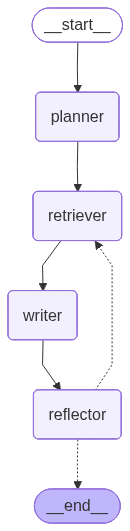

In [12]:
def should_retry(state: AgentState) -> str:
    return "retriever" if state.get("needs_revision", False) else END


def build_graph():
    g = StateGraph(AgentState)

    g.add_node("planner", planner_agent)
    g.add_node("retriever", retriever_agent)
    g.add_node("writer", writer_agent)
    g.add_node("reflector", reflector_agent)

    g.set_entry_point("planner")

    g.add_edge("planner", "retriever")
    g.add_edge("retriever", "writer")
    g.add_edge("writer", "reflector")
    g.add_conditional_edges("reflector", should_retry, {"retriever": "retriever", END: END})

    app = g.compile()
    return app


app = build_graph()
app

In [13]:
test_response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[
        {"role": "user", "content": "Say hello in one sentence."}
    ],
    temperature=0.2,
)

print("TYPE:", type(test_response))
print("RAW RESPONSE:")
print(test_response)

print("\nEXTRACTED TEXT:")
print(extract_text(test_response))

TYPE: <class 'openai.types.chat.chat_completion.ChatCompletion'>
RAW RESPONSE:
ChatCompletion(id='chatcmpl-97', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Hello, how are you today?', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None))], created=1776098998, model='llama3.1', object='chat.completion', service_tier=None, system_fingerprint='fp_ollama', usage=CompletionUsage(completion_tokens=8, prompt_tokens=16, total_tokens=24, completion_tokens_details=None, prompt_tokens_details=None))

EXTRACTED TEXT:
Hello, how are you today?


In [14]:
def run_pipeline(query: str) -> AgentState:
    state: AgentState = {
        "query": query,
        "sub_questions": [],
        "scratchpad": [],
        "draft_answer": "",
        "final_answer": "",
        "needs_revision": False,
        "iteration": 0,
        "reflection_notes": "",
    }
    final_state = app.invoke(state)
    return final_state

In [15]:
user_query = input("Enter your research question: ").strip()
if not user_query:
    raise ValueError("Please enter a non-empty question.")

state = run_pipeline(user_query)

print("=== Original Query ===")
print(state["query"], "\n")

print("=== Planner Sub-questions ===")
for i, sq in enumerate(state.get("sub_questions", []), 1):
    print(f"{i}. {sq}")
print()

print("=== Retrieved Passages (first 3) ===")
for i, p in enumerate(state.get("scratchpad", [])[:3], 1):
    src = p.get("source", "unknown")
    page = p.get("page", "?")
    content = p.get("content", "")
    print(f"[{i}] Source: {src}  Page: {page}")
    print(content[:600], "...\n")

print("=== Reflection Notes ===")
print(state.get("reflection_notes", ""), "\n")

print("=== Final Answer ===")
print(state.get("final_answer") or state.get("draft_answer", ""))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5931.72it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13201.73it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14431.71it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embe

=== Original Query ===
How do multi‑agent, reflection‑based RAG systems improve groundedness and reliability compared to single‑step RAG question answering? 

=== Planner Sub-questions ===
1. What are the benefits of using a multi-agent architecture in RAG systems?
2. How does reflection-based feedback improve the performance of RAG systems?
3. What is the effect of grounding on the reliability of RAG question answering compared to single-step approaches?

=== Retrieved Passages (first 3) ===
[1] Source: data/Ai Agents vs Agentic AI.pdf  Page: 21
ing or minimizing inconsistencies due to divergent contextual 
views. When implemented across a multi-agent system, RAG 
helps maintain shared accuracy, enhances goal alignment, and 
reduces inter-agent misinformation propagation.
2. Tool-Augmented Reasoning (Function Calling): AI Agents 
benefit significantly from function calling, which extends their 
ability to interact with real-world systems [171,217]. Agents 
can query APIs, run local sc

In [16]:
test_questions = [
    "What is retrieval-augmented generation (RAG) and why is it useful for knowledge-intensive tasks?",
    "What role does reflection play in multi-agent LLM systems such as ReAct-style agents?",
    "How does LangGraph support multi-agent coordination for research assistants?",
    "What are key evaluation dimensions for RAG systems in terms of context and answer quality?",
    "Why is groundedness important in scholarly question answering systems?",
]

In [17]:
rows = []

for q in test_questions:
    st = run_pipeline(q)
    answer = st.get("final_answer") or st.get("draft_answer", "")
    sub_qs = st.get("sub_questions", [])
    num_passages = len(st.get("scratchpad", []))

    rows.append({
        "question": q,
        "sub_questions": " || ".join(sub_qs),
        "num_passages": num_passages,
        "answer_preview": answer[:400] + ("..." if len(answer) > 400 else ""),
    })

df_runs = pd.DataFrame(rows)
df_runs

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7411.19it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13565.27it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12612.05it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embe

,question,sub_questions,num_passages,answer_preview
0,What is retrieval-augmented generation (RAG) a...,What is retrieval-augmented generation (RAG)? ...,7,Retrieval-Augmented Generation (RAG) is a para...
1,What role does reflection play in multi-agent ...,What is the purpose of reflection in multi-age...,6,**Introduction**\n\nReflection plays a vital r...
2,How does LangGraph support multi-agent coordin...,What is LangGraph and how does it relate to re...,6,LangGraph supports multi-agent coordination fo...
3,What are key evaluation dimensions for RAG sys...,What are the key evaluation metrics for RAG sy...,6,**Evaluation Dimensions for RAG Systems**\n\nT...
4,Why is groundedness important in scholarly que...,What are the benefits of grounding in scholarl...,5,Groundedness is crucial in scholarly question ...


In [18]:
df_scores = pd.DataFrame({
    "question": test_questions,
    "context_relevance": [None] * len(test_questions),
    "groundedness": [None] * len(test_questions),
    "answer_relevance": [None] * len(test_questions),
})

df_scores

,question,context_relevance,groundedness,answer_relevance
0,What is retrieval-augmented generation (RAG) a...,None,None,None
1,What role does reflection play in multi-agent ...,None,None,None
2,How does LangGraph support multi-agent coordin...,None,None,None
3,What are key evaluation dimensions for RAG sys...,None,None,None
4,Why is groundedness important in scholarly que...,None,None,None


In [19]:
if df_scores["answer_relevance"].notnull().all():
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(df_scores)), df_scores["answer_relevance"])
    plt.xticks(range(len(df_scores)), [f"Q{i+1}" for i in range(len(df_scores))])
    plt.ylabel("Answer Relevance (1–5)")
    plt.title("Answer Relevance per Question")
    plt.show()
else:
    print("Fill in df_scores manually to plot evaluation results.")

Fill in df_scores manually to plot evaluation results.
